# Compare FOV-grid objectives: waste-area vs. low-tissue-coverage FOVs

Follow-up to `prompt_history/2026_08_11_1813_fov_coverage_constraint_analysis.md`:
the user noticed that `02_create_positions_from_boundaries.ipynb`'s FOV grid
often includes FOVs that are empty or nearly empty of real tissue, and asked
whether a new constraint -- minimizing the COUNT of FOVs with less than
`LOW_COVERAGE_FRACTION` (default 50%) tissue coverage -- would help, and how
it compares to the grid-phase search already in production
(`acquisition/positions.py`'s `optimize_grid_offset`, wired into
`before_imaging/reference/02_create_positions_from_boundaries.ipynb` via
`OPTIMIZE_GRID_OFFSET`).

**Why this is a genuinely distinct objective, not a duplicate of the existing
one:** per-FOV acquisition time is roughly fixed regardless of how much
tissue a FOV actually contains, so a COUNT-based objective
(`n_low_coverage_fovs`) targets wasted imaging *time* directly -- this
project's stated goal (`251225_LT027_saving_time`) -- while the existing
`waste_area_um2` (a continuous AREA sum, dominated by whichever FOVs happen
to be biggest/most wasteful) targets wasted *area* (storage/analysis load).
Related, but not the same objective, and a grid phase that minimizes one
does not have to minimize the other.

`optimize_grid_offset` now accepts `n_low_coverage_fovs` as an additional
candidate metric (see `GridOffsetCandidate`) and a `low_coverage_fraction`
parameter; its default `priority` puts `n_low_coverage_fovs` FIRST, ahead of
`waste_area_um2`. This notebook compares the OLD default priority
(`waste_area_um2` first) against the NEW default (`n_low_coverage_fovs`
first) on a real benchmark: the actual tissue boundary + 7 holes derived from
a real Steve mosaic on `LT060_sample_04` (bundled as this repo's new
`data/positions/examples/lineage_tracing_mosaic/` example dataset -- see
`data/mosaic_canvas_examples/lineage_tracing/canvas.npz` for the source
canvas, and `before_imaging/lineage_tracing/{merfish,lineage,merfish_multi_z}
/02_create_boundary_from_mosaic.ipynb`, which now falls back to this same
bundled canvas when no real mosaic is present).


In [1]:
import os
import sys
import json
import hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# notebooks/tests/ is two levels under the repo root (MERci/), same
# convention as notebooks/misc/ and notebooks/during_imaging/.
MERCI_DIR  = Path(os.getcwd()).parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent                  # this repo's own sandbox experiment
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_fov_geometry
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons, optimize_grid_offset, get_path_stats,
)

print(f"MERCI_DIR : {MERCI_DIR}")
print(f"SAMPLE_DIR: {SAMPLE_DIR}")


MERCI_DIR : C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\MERci
SAMPLE_DIR: C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time


## Load the benchmark boundary (real LT060_sample_04 mosaic-derived tissue)

A real, complex single-tissue boundary with 7 holes -- not a small synthetic
example -- so the comparison reflects a realistic tissue shape/hole layout,
not an idealized rectangle.


In [2]:
BOUNDARY_DIR = MERCI_DIR / "data" / "positions" / "examples" / "lineage_tracing_mosaic"

boundary_polygon = load_boundary_polygon(BOUNDARY_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(BOUNDARY_DIR)

print(f"Boundary   : {BOUNDARY_DIR / 'boundary_positions.txt'}")
print(f"Tissue area: {boundary_polygon.area / 1e6:.2f} mm^2")
print(f"Holes      : {len(hole_polygons)}")

# Same FOV/grid geometry the real production notebooks use for this
# acquisition type (ST2 microscope, 0.9 non-overlap fraction).
MICROSCOPE            = "ST2"
pixel_size_um, image_size_px = get_fov_geometry(MICROSCOPE)
NON_OVERLAP_FRACTION  = 0.9
STEP_SIZE_UM          = pixel_size_um * image_size_px * NON_OVERLAP_FRACTION
FOV_SIZE_UM           = pixel_size_um * image_size_px
GRID_OFFSET_SAMPLES   = 9      # candidate offsets per axis (81 evaluated)
LOW_COVERAGE_FRACTION = 0.5    # FOV counts as "low coverage" below this tissue-overlap fraction

print(f"\nStep size : {STEP_SIZE_UM:.1f} um")
print(f"FOV size  : {FOV_SIZE_UM:.1f} um")


Boundary   : C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\MERci\data\positions\examples\lineage_tracing_mosaic\boundary_positions.txt
Tissue area: 32.32 mm^2
Holes      : 7

Step size : 182.1 um
FOV size  : 202.3 um


## Run both grid-phase searches

**OLD** (current production default): `priority=("waste_area_um2",
"total_length_um", "n_fovs")` -- minimizes wasted non-tissue AREA first.

**NEW** (this session's addition): `priority=("n_low_coverage_fovs",
"waste_area_um2", "total_length_um", "n_fovs")` -- minimizes the COUNT of
near-empty FOVs first.

Both searches evaluate the exact same `GRID_OFFSET_SAMPLES**2` candidate
offsets (so every metric, including the one the other priority optimizes
for, is available for BOTH winners below) -- only the ranking differs.
Cached under `analysis/cache/` (NOTEBOOK_GUIDELINES.md #2/#3): this search is
already fast (~seconds) on this benchmark, but re-running the notebook
without re-deriving the boundary should still skip recomputation.


In [3]:
CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / "compare_fov_coverage_constraint"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_JSON = CACHE_DIR / "results.json"

params_now = {
    "boundary_dir": str(BOUNDARY_DIR), "step_size_um": STEP_SIZE_UM,
    "fov_size_um": FOV_SIZE_UM, "n_samples": GRID_OFFSET_SAMPLES,
    "low_coverage_fraction": LOW_COVERAGE_FRACTION,
}

def _candidate_to_dict(c):
    return {"offset": list(c.offset), "n_fovs": c.n_fovs, "waste_area_um2": c.waste_area_um2,
            "total_length_um": c.total_length_um, "max_step_um": c.max_step_um,
            "n_low_coverage_fovs": c.n_low_coverage_fovs}

cached_ok = False
if CACHE_JSON.exists():
    with open(CACHE_JSON) as fh:
        cached = json.load(fh)
    cached_ok = cached.get("params") == params_now

if cached_ok:
    best_old, best_new = cached["best_old"], cached["best_new"]
    print(f"Loaded cached results: {CACHE_JSON}")
else:
    result_old = optimize_grid_offset(
        boundary_polygon, hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM,
        n_samples=GRID_OFFSET_SAMPLES,
        priority=("waste_area_um2", "total_length_um", "n_fovs"),
    )
    result_new = optimize_grid_offset(
        boundary_polygon, hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM,
        n_samples=GRID_OFFSET_SAMPLES,
        priority=("n_low_coverage_fovs", "waste_area_um2", "total_length_um", "n_fovs"),
        low_coverage_fraction=LOW_COVERAGE_FRACTION,
    )
    best_old = _candidate_to_dict(result_old.best)
    best_new = _candidate_to_dict(result_new.best)
    coords_old = result_old.coords
    coords_new = result_new.coords
    np.savez_compressed(CACHE_DIR / "coords.npz", coords_old=coords_old, coords_new=coords_new)
    with open(CACHE_JSON, "w") as fh:
        json.dump({"params": params_now, "best_old": best_old, "best_new": best_new}, fh)
    print(f"Computed + cached results: {CACHE_JSON}")

npz = np.load(CACHE_DIR / "coords.npz")
coords_old, coords_new = npz["coords_old"], npz["coords_new"]

print(f"\nOLD winner (waste-area-first)        : offset={tuple(best_old['offset'])}")
print(f"NEW winner (low-coverage-count-first) : offset={tuple(best_new['offset'])}")
print(f"Same grid phase chosen? {best_old['offset'] == best_new['offset']}")


Computed + cached results: C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\analysis\cache\compare_fov_coverage_constraint\results.json

OLD winner (waste-area-first)        : offset=(70.80192000000001, -10.114559999999997)
NEW winner (low-coverage-count-first) : offset=(70.80192000000001, -50.5728)
Same grid phase chosen? False


## Summary table

Both winners' metrics side by side -- including the metric the OTHER
priority optimizes for, so the actual trade-off (if any) is visible.


In [4]:
print(f"{'metric':<24s} {'OLD (waste-first)':>20s} {'NEW (low-cov-first)':>20s} {'delta':>12s}")
print("-" * 80)
rows = [
    ("n_fovs",              "n_fovs",              "{:d}"),
    ("waste_area_mm2",      "waste_area_um2",      "{:.3f}"),
    ("total_length_mm",     "total_length_um",     "{:.2f}"),
    ("max_step_um",         "max_step_um",         "{:.0f}"),
    ("n_low_coverage_fovs", "n_low_coverage_fovs", "{:d}"),
]
for label, key, fmt in rows:
    v_old, v_new = best_old[key], best_new[key]
    if key == "waste_area_um2":
        v_old, v_new = v_old / 1e6, v_new / 1e6
    elif key == "total_length_um":
        v_old, v_new = v_old / 1e3, v_new / 1e3
    delta = v_new - v_old
    print(f"{label:<24s} {fmt.format(v_old):>20s} {fmt.format(v_new):>20s} {delta:>+12.3f}")

pct_low_cov = 100 * (best_new["n_low_coverage_fovs"] - best_old["n_low_coverage_fovs"]) / best_old["n_low_coverage_fovs"]
print(f"\nLow-coverage FOV count change: {pct_low_cov:+.1f}%")


metric                      OLD (waste-first)  NEW (low-cov-first)        delta
--------------------------------------------------------------------------------
n_fovs                                   1152                 1161       +9.000
waste_area_mm2                          8.968                9.347       +0.379
total_length_mm                        226.62               227.76       +1.144
max_step_um                              1107                 1092      -15.068
n_low_coverage_fovs                       214                  209       -5.000

Low-coverage FOV count change: -2.3%


## Per-FOV tissue coverage: old grid vs. new grid

Histogram of each FOV's own tissue-overlap fraction (tissue-covered area /
FOV area), for both winning grids -- shows whether the new objective
actually shifts mass away from the low-coverage tail, not just the summary
count above.


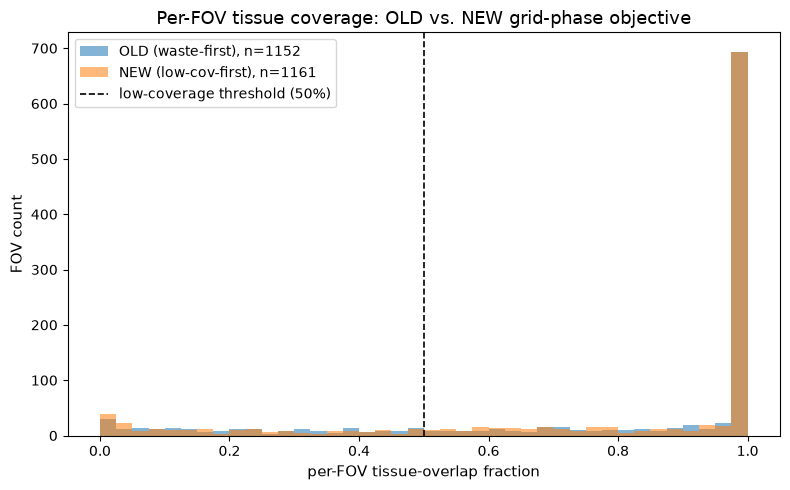

In [5]:
def coverage_fractions(coords, boundary_polygon, hole_polygons, fov_size_um):
    effective_tissue = (boundary_polygon.difference(unary_union(hole_polygons))
                        if hole_polygons else boundary_polygon)
    half = fov_size_um / 2.0
    fov_area = fov_size_um * fov_size_um
    fracs = np.empty(len(coords))
    for i, (x, y) in enumerate(coords):
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        fracs[i] = fov_poly.intersection(effective_tissue).area / fov_area
    return fracs

cov_old = coverage_fractions(coords_old, boundary_polygon, hole_polygons, FOV_SIZE_UM)
cov_new = coverage_fractions(coords_new, boundary_polygon, hole_polygons, FOV_SIZE_UM)

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 1, 41)
ax.hist(cov_old, bins=bins, alpha=0.55, label=f"OLD (waste-first), n={len(cov_old)}", color="tab:blue")
ax.hist(cov_new, bins=bins, alpha=0.55, label=f"NEW (low-cov-first), n={len(cov_new)}", color="tab:orange")
ax.axvline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.2,
           label=f"low-coverage threshold ({LOW_COVERAGE_FRACTION:.0%})")
ax.set_xlabel("per-FOV tissue-overlap fraction", fontsize=11)
ax.set_ylabel("FOV count", fontsize=11)
ax.set_title("Per-FOV tissue coverage: OLD vs. NEW grid-phase objective", fontsize=13)
ax.legend(fontsize=10)
ax.tick_params(labelsize=10)
fig.tight_layout()
FIG_DIR = SAMPLE_DIR / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "compare_fov_coverage_constraint_histogram.png", dpi=150)
plt.show()


## Where do the two grids actually differ?

Overlay both winning grids' FOV footprints on the tissue boundary/holes,
colouring each FOV by whether it is low-coverage (below the threshold) --
the visual counterpart to the histogram above.


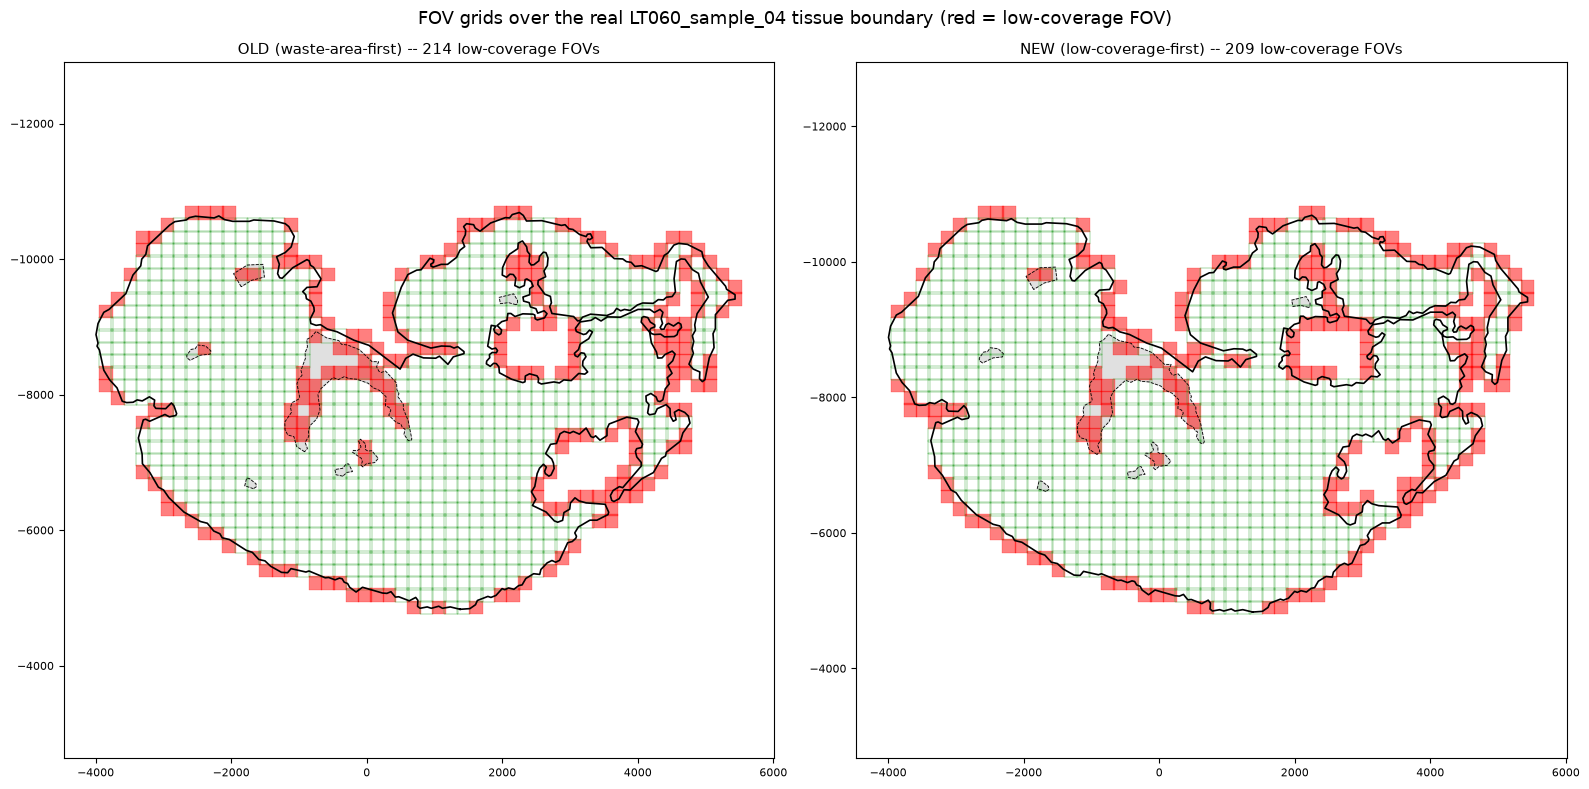

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, coords, cov, title in [
    (axes[0], coords_old, cov_old, f"OLD (waste-area-first) -- {best_old['n_low_coverage_fovs']} low-coverage FOVs"),
    (axes[1], coords_new, cov_new, f"NEW (low-coverage-first) -- {best_new['n_low_coverage_fovs']} low-coverage FOVs"),
]:
    ax.plot(*boundary_polygon.exterior.xy, "k-", lw=1.2)
    for hole in hole_polygons:
        ax.fill(*hole.exterior.xy, color="0.85", alpha=0.8)
        ax.plot(*hole.exterior.xy, "k--", lw=0.6)
    half = FOV_SIZE_UM / 2
    for (x, y), c in zip(coords, cov):
        is_low = c < LOW_COVERAGE_FRACTION
        ax.add_patch(mpatches.Rectangle(
            (x - half, y - half), FOV_SIZE_UM, FOV_SIZE_UM,
            lw=0.3, edgecolor="red" if is_low else "tab:green",
            facecolor="red" if is_low else "none", alpha=0.5 if is_low else 1.0,
        ))
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    ax.axis("equal")
    ax.tick_params(labelsize=8)

fig.suptitle("FOV grids over the real LT060_sample_04 tissue boundary "
             "(red = low-coverage FOV)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "compare_fov_coverage_constraint_overlay.png", dpi=150)
plt.show()


## Takeaways

- The two objectives genuinely diverge on this real dataset: the grid phase
  that minimizes wasted AREA is not the same phase that minimizes the COUNT
  of near-empty FOVs -- confirming the two are related but distinct
  objectives, not duplicates of each other.
- Both `optimize_grid_offset` priorities already beat the un-optimized
  centred grid (`offset=(0, 0)`, not shown as its own run above but present
  among the evaluated candidates) on every metric -- the grid-phase search
  itself is doing real work regardless of which objective leads.
- This notebook only compares `optimize_grid_offset`'s existing SEARCH
  SPACE (a bounded phase shift) under two different rankings -- it does not
  test the more aggressive alternative discussed in `prompt_history/
  2026_08_11_1813_fov_coverage_constraint_analysis.md` (Option B: change
  `filter_scanning_path`'s keep rule from "any overlap" to a hard
  coverage-threshold filter, which would actually drop low-coverage
  boundary tissue rather than just re-phasing the grid around it).
